In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

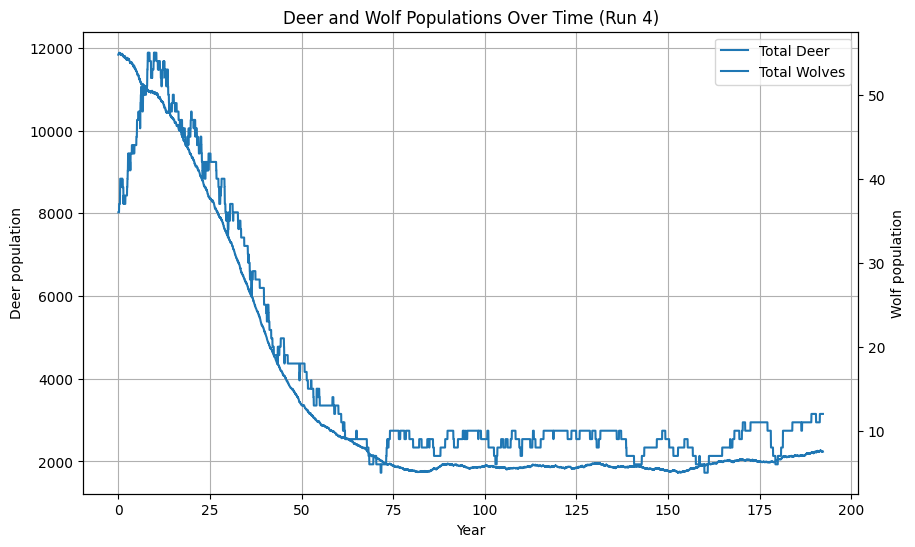

In [ ]:
df = pd.read_csv("weekly_model_multiple_runs.csv")

run_id = 4
df = df[df["Run"] == run_id].copy()

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

ax1.plot(df["Year"], df["Total Deer"], label="Total Deer", color="orange")
ax2.plot(df["Year"], df["Total Wolves"], label="Total Wolves")

ax1.set_xlabel("Year")
ax1.set_ylabel("Deer population")
ax2.set_ylabel("Wolf population")
ax1.set_title(f"Deer and Wolf Populations Over Time (Run {run_id})")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

ax1.grid(True)
plt.show()

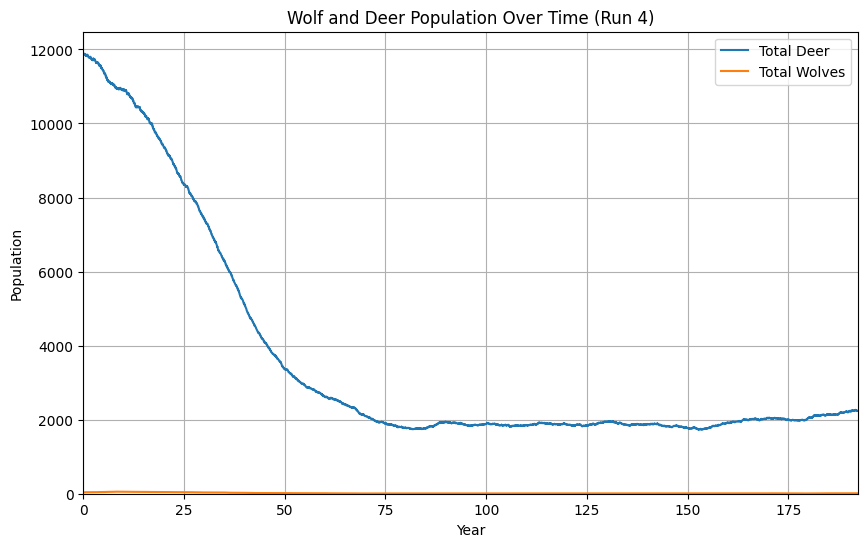

In [3]:

df = pd.read_csv("weekly_model_multiple_runs.csv")

run_id = 4
df = df[df["Run"] == run_id].copy().reset_index(drop=True)

if "Year" not in df.columns:
    if "Step" in df.columns:
        df["Year"] = df["Step"] / 52
    else:
        df["Year"] = df.index / 52

fig, ax = plt.subplots(figsize=(10, 6))

def update(frame):
    ax.clear()

    ax.plot(df["Year"][:frame], df["Total Deer"][:frame], label="Total Deer")
    ax.plot(df["Year"][:frame], df["Total Wolves"][:frame], label="Total Wolves")

    ax.set_title(f"Wolf and Deer Population Over Time (Run {run_id})")
    ax.set_xlabel("Year")
    ax.set_ylabel("Population")
    ax.legend()
    ax.grid(True)

    ax.set_xlim(df["Year"].min(), df["Year"].max())
    ax.set_ylim(0, max(df["Total Deer"].max(), df["Total Wolves"].max()) * 1.05)

anim = FuncAnimation(fig, update, frames=len(df), interval=50, repeat=False)
anim.save(f"wolf_deer_run_{run_id}.gif", writer="pillow", fps=20)

plt.show()